# 🍕 Custom CNNs vs. Transfer Learning
### Assignment: Food-101 Subset (10 Classes) | MobileNetV2

**Setup Summary:**
- **Dataset:** Food-101 — 10 classes subset
- **Phase 1 (Scratch):** Custom CNN with RMSprop
- **Phase 2 (Transfer):** MobileNetV2 frozen base + Adam
- **Training:** Up to 30 epochs with Early Stopping on `val_loss`

---

## 0️⃣ Setup & Dependencies

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import RMSprop, Adam

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {tf.config.list_physical_devices("GPU")}')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

TensorFlow version : 2.19.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1️⃣ Configuration

In [8]:
# ── Dataset ───────────────────────────────────────────────────────────────────
# 10 classes chosen from Food-101 for a balanced, manageable subset
SELECTED_CLASSES = [
    'pizza', 'sushi', 'hamburger', 'hot_dog', 'ice_cream',
    'chocolate_cake', 'french_fries', 'fried_rice', 'ramen', 'tacos'
]
NUM_CLASSES   = len(SELECTED_CLASSES)   # 10
CLASS_TO_IDX  = {c: i for i, c in enumerate(SELECTED_CLASSES)}

# ── Image & Training ──────────────────────────────────────────────────────────
IMG_SIZE      = 128          # resize to 128×128
BATCH_SIZE    = 32
MAX_EPOCHS    = 30
ES_PATIENCE   = 4            # early-stopping patience

# ── Optimizers ────────────────────────────────────────────────────────────────
LR_SCRATCH    = 1e-3         # RMSprop learning rate  (Phase 1)
LR_TL         = 1e-3         # Adam learning rate     (Phase 2)

print('Configuration loaded ✓')
print(f'  Classes  : {SELECTED_CLASSES}')
print(f'  IMG_SIZE : {IMG_SIZE}×{IMG_SIZE}')

Configuration loaded ✓
  Classes  : ['pizza', 'sushi', 'hamburger', 'hot_dog', 'ice_cream', 'chocolate_cake', 'french_fries', 'fried_rice', 'ramen', 'tacos']
  IMG_SIZE : 128×128


## 2️⃣ Load & Prepare the Food-101 Subset

In [ ]:
# Load full Food-101 from TensorFlow Datasets
print('Downloading / loading Food-101 …')
(ds_train_raw, ds_val_raw), ds_info = tfds.load(
    'food101',
    split=['train', 'validation'],
    as_supervised=True,
    with_info=True
)

# Map original Food-101 label ids → class names using ds_info
label_names = ds_info.features['label'].names   # list of 101 strings
print(f'Total Food-101 classes : {len(label_names)}')

# Build a tensor of the label indices we want to keep
selected_ids = tf.constant([label_names.index(c) for c in SELECTED_CLASSES], dtype=tf.int64)

def remap_label(image, label):
    """Return (image, new_label) only for selected classes; new_label 0-9."""
    new_label = tf.where(tf.equal(selected_ids, label))
    return image, tf.cast(new_label[0][0], tf.int32)

def is_selected(_, label):
    """Keep only samples whose label is in selected_ids."""
    return tf.reduce_any(tf.equal(selected_ids, label))

ds_train_filtered = ds_train_raw.filter(is_selected).map(remap_label)
ds_val_filtered   = ds_val_raw.filter(is_selected).map(remap_label)

In [5]:
# ── Preprocessing pipelines ───────────────────────────────────────────────────

def preprocess_scratch(image, label):
    """Resize + normalise to [0, 1] for the custom CNN."""
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def preprocess_mobilenet(image, label):
    """Resize + MobileNetV2 preprocessor (scales to [-1, 1])."""
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

def augment(image, label):
    """Light augmentation (flip + brightness + contrast)."""
    image = tf.image.random_flip_left_right(image, seed=SEED)
    image = tf.image.random_brightness(image, 0.15, seed=SEED)
    image = tf.image.random_contrast(image, 0.8, 1.2, seed=SEED)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def augment_mobilenet(image, label):
    """Augmentation for MobileNetV2 pipeline (values in [-1,1])."""
    image = tf.image.random_flip_left_right(image, seed=SEED)
    image = tf.image.random_brightness(image, 0.15, seed=SEED)
    image = tf.image.random_contrast(image, 0.8, 1.2, seed=SEED)
    image = tf.clip_by_value(image, -1.0, 1.0)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

# ── Scratch CNN datasets ──────────────────────────────────────────────────────
train_scratch = (
    ds_train_filtered
    .map(preprocess_scratch, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .shuffle(2000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_scratch = (
    ds_val_filtered
    .map(preprocess_scratch, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── MobileNetV2 datasets ──────────────────────────────────────────────────────
train_tl = (
    ds_train_filtered
    .map(preprocess_mobilenet, num_parallel_calls=AUTOTUNE)
    .map(augment_mobilenet, num_parallel_calls=AUTOTUNE)
    .shuffle(2000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_tl = (
    ds_val_filtered
    .map(preprocess_mobilenet, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

Pipelines ready ✓


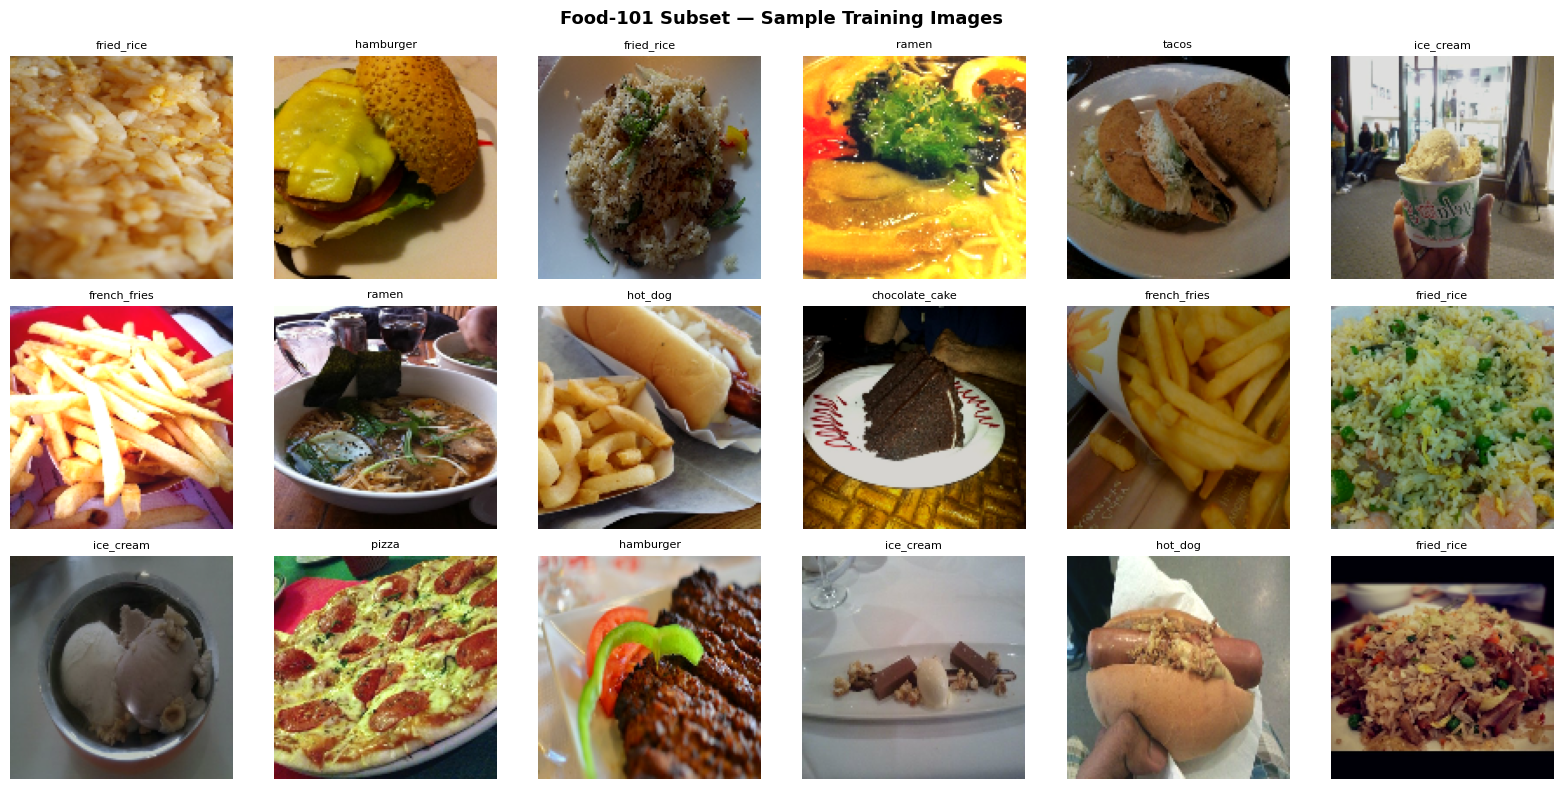

In [6]:
# ── Quick sanity-check: visualise one batch ───────────────────────────────────
sample_images, sample_labels = next(iter(train_scratch))

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].numpy())
    ax.set_title(SELECTED_CLASSES[sample_labels[i].numpy()], fontsize=8)
    ax.axis('off')
plt.suptitle('Food-101 Subset — Sample Training Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

## 3️⃣ Phase 1 — Custom CNN from Scratch (RMSprop)

In [7]:
def build_scratch_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):

    model = models.Sequential(name='Custom_CNN_Scratch')

    # ── Block 1 ──────────────────────────────────────────────────────────────
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                            input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # ── Block 2 ──────────────────────────────────────────────────────────────
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # ── Block 3 ──────────────────────────────────────────────────────────────
    model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # ── Block 4 ──────────────────────────────────────────────────────────────
    model.add(layers.Conv2D(256, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.GlobalAveragePooling2D())

    # ── Dense head ───────────────────────────────────────────────────────────
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.4))           # Dropout layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=RMSprop(learning_rate=LR_SCRATCH),   # RMSprop
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_scratch = build_scratch_cnn()
model_scratch.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Custom_CNN_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,698 (1.75 MB)

 Trainable params: 457,738 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

In [9]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
es_scratch = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=ES_PATIENCE,
    restore_best_weights=True,
    verbose=1
)
rlrop_scratch = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

print('Training Phase 1 — Custom CNN')
history_scratch = model_scratch.fit(
    train_scratch,
    validation_data=val_scratch,
    epochs=MAX_EPOCHS,
    callbacks=[es_scratch, rlrop_scratch],
    verbose=1
)

epochs_scratch = len(history_scratch.history['accuracy'])
best_val_acc_scratch = max(history_scratch.history['val_accuracy'])
print(f'\n✅ Phase 1 done | Epochs run: {epochs_scratch} | '
      f'Best val accuracy: {best_val_acc_scratch:.4f}')

Training Phase 1 — Custom CNN
Epoch 1/30
    235/Unknown 103s 308ms/step - accuracy: 0.2119 - loss: 2.2996

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


235/235 ━━━━━━━━━━━━━━━━━━━━ 134s 440ms/step - accuracy: 0.2624 - loss: 2.1388 - val_accuracy: 0.1044 - val_loss: 3.2381 - learning_rate: 0.0010
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 117s 401ms/step - accuracy: 0.3823 - loss: 1.8018 - val_accuracy: 0.3976 - val_loss: 1.7133 - learning_rate: 0.0010
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 144s 510ms/step - accuracy: 0.4692 - loss: 1.5695 - val_accuracy: 0.4048 - val_loss: 1.8250 - learning_rate: 0.0010
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 149s 531ms/step - accuracy: 0.5381 - loss: 1.3770 - val_accuracy: 0.3344 - val_loss: 2.2954 - learning_rate: 0.0010
Epoch 5/30
233/235 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.5777 - loss: 1.2792
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
235/235 ━━━━━━━━━━━━━━━━━━━━ 141s 503ms/step - accuracy: 0.5965 - loss: 1.2298 - val_accuracy: 0.3560 - val_loss: 2.6275 - learning_rate: 0.0010
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 117s 393ms/step - accuracy: 0.6805 - l

## 4️⃣ Phase 2 — Transfer Learning with MobileNetV2 (Adam)

In [12]:
def build_transfer_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):

    # ── Frozen base ───────────────────────────────────────────────────────────
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False   # freeze all base weights

    # ── Custom head ───────────────────────────────────────────────────────────
    inputs  = tf.keras.Input(shape=input_shape)

    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)   # GAP layer
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs, name='MobileNetV2_TL')
    model.compile(
        optimizer=Adam(learning_rate=LR_TL),       # Adam
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_tl = build_transfer_model()
print(f'MobileNetV2 base layers (frozen): '
      f'{sum(not l.trainable for l in model_tl.layers)}')
model_tl.summary()

MobileNetV2 base layers (frozen): 1


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
es_tl = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=ES_PATIENCE,
    restore_best_weights=True,
    verbose=1
)
rlrop_tl = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

print('Training Phase 2 — MobileNetV2 Transfer Learning')
history_tl = model_tl.fit(
    train_tl,
    validation_data=val_tl,
    epochs=MAX_EPOCHS,
    callbacks=[es_tl, rlrop_tl],
    verbose=1
)

epochs_tl = len(history_tl.history['accuracy'])
best_val_acc_tl = max(history_tl.history['val_accuracy'])
print(f'\n✅ Phase 2 done | Epochs run: {epochs_tl} | '
      f'Best val accuracy: {best_val_acc_tl:.4f}')

Training Phase 2 — MobileNetV2 Transfer Learning
Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 150s 508ms/step - accuracy: 0.6676 - loss: 1.0379 - val_accuracy: 0.8588 - val_loss: 0.4486 - learning_rate: 0.0010
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 128s 448ms/step - accuracy: 0.8025 - loss: 0.6069 - val_accuracy: 0.8704 - val_loss: 0.4033 - learning_rate: 0.0010
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 113s 385ms/step - accuracy: 0.8323 - loss: 0.5164 - val_accuracy: 0.8784 - val_loss: 0.3807 - learning_rate: 0.0010
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 115s 390ms/step - accuracy: 0.8495 - loss: 0.4679 - val_accuracy: 0.8840 - val_loss: 0.3683 - learning_rate: 0.0010
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 139s 495ms/step - accuracy: 0.8563 - loss: 0.4267 - val_accuracy: 0.8876 - val_loss: 0.3645 - learning_rate: 0.0010
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 116s 389ms/step - accuracy: 0.8643 - loss: 0.4077 - val_accuracy: 0.8800 - val_loss: 0.3699 - learning_rate: 0.0010
Epoch 7/30
235/

## 5️⃣ Visualisations

Saved → plot_scratch.png


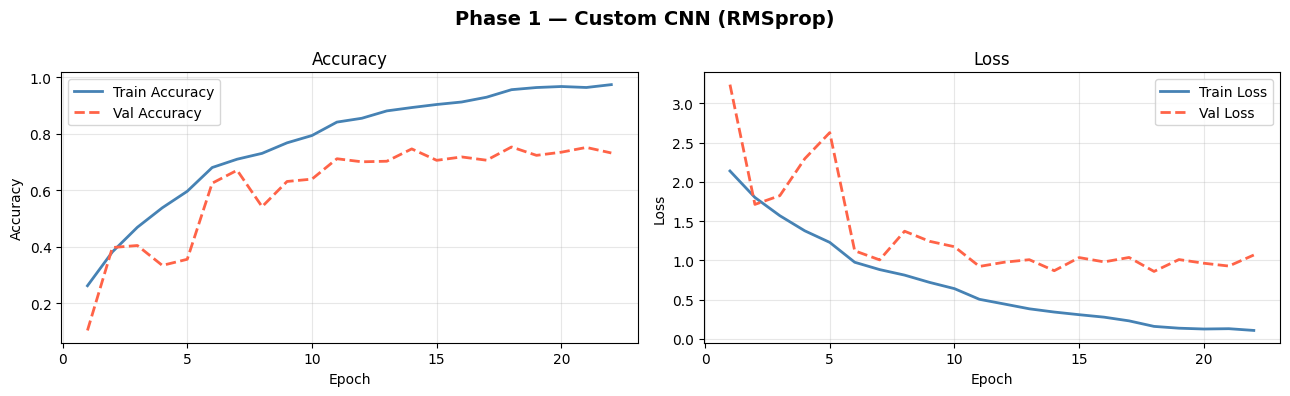

Saved → plot_tl.png


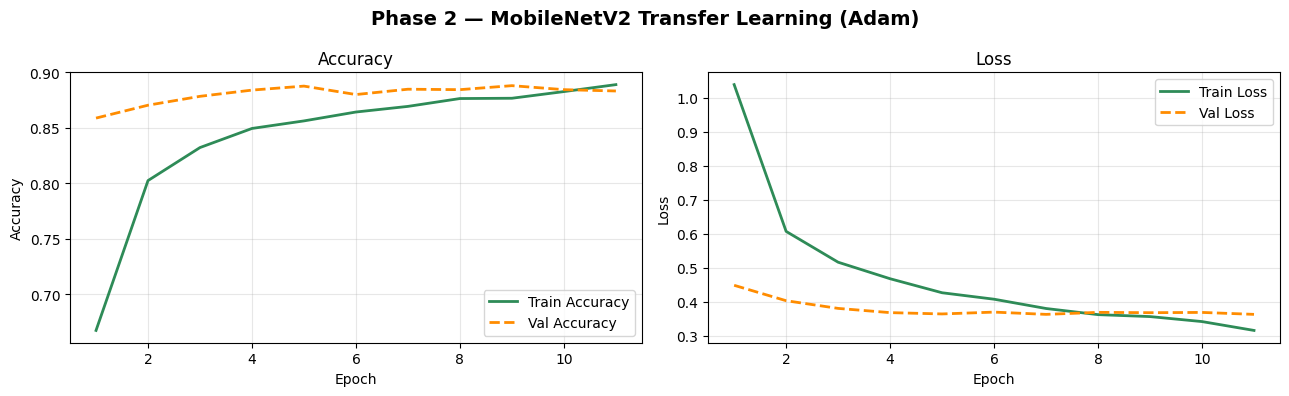

In [14]:
def plot_history(history, title, color_train='steelblue', color_val='tomato', save_as=None):
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss    = history.history['loss']
    val_loss= history.history['val_loss']
    ep      = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Accuracy
    ax1.plot(ep, acc,     color=color_train, lw=2, label='Train Accuracy')
    ax1.plot(ep, val_acc, color=color_val,   lw=2, linestyle='--', label='Val Accuracy')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Loss
    ax2.plot(ep, loss,     color=color_train, lw=2, label='Train Loss')
    ax2.plot(ep, val_loss, color=color_val,   lw=2, linestyle='--', label='Val Loss')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_as}')
    plt.show()

plot_history(history_scratch,
             'Phase 1 — Custom CNN (RMSprop)',
             save_as='plot_scratch.png')

plot_history(history_tl,
             'Phase 2 — MobileNetV2 Transfer Learning (Adam)',
             color_train='seagreen', color_val='darkorange',
             save_as='plot_tl.png')

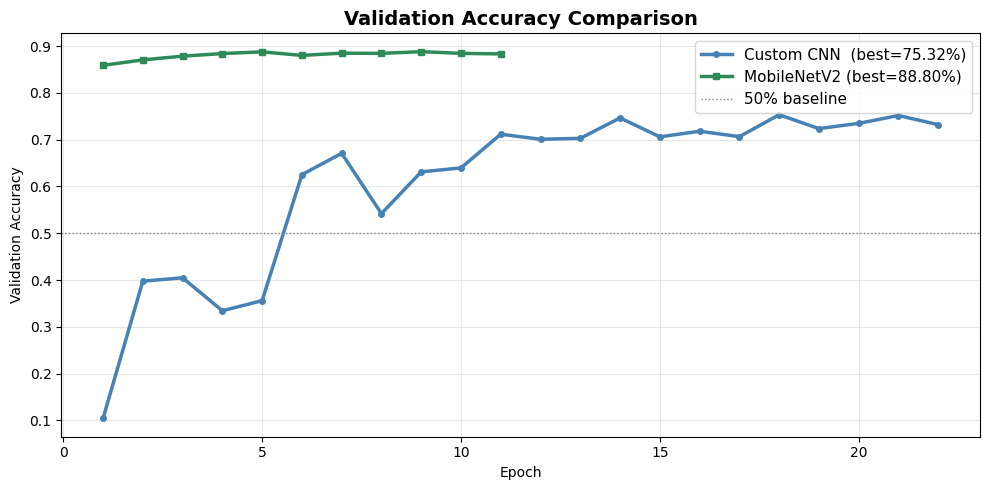

In [15]:
# ── Side-by-side val accuracy comparison ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ep_s = range(1, epochs_scratch + 1)
ep_t = range(1, epochs_tl + 1)

ax.plot(ep_s, history_scratch.history['val_accuracy'],
        color='steelblue', lw=2.5, marker='o', markersize=4,
        label=f'Custom CNN  (best={best_val_acc_scratch:.2%})')
ax.plot(ep_t, history_tl.history['val_accuracy'],
        color='seagreen', lw=2.5, marker='s', markersize=4,
        label=f'MobileNetV2 (best={best_val_acc_tl:.2%})')

ax.axhline(0.5, color='grey', lw=1, linestyle=':', label='50% baseline')
ax.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6️⃣ Results Summary

In [16]:
# ── Compute 'usable' accuracy threshold (≥50%) convergence epoch ──────────────
USABLE_THRESHOLD = 0.50

def epochs_to_usable(val_acc_list, threshold=USABLE_THRESHOLD):
    for i, acc in enumerate(val_acc_list, 1):
        if acc >= threshold:
            return i
    return 'Never reached'

conv_scratch = epochs_to_usable(history_scratch.history['val_accuracy'])
conv_tl      = epochs_to_usable(history_tl.history['val_accuracy'])

print('=' * 58)
print(f'{"METRIC":<35} {"SCRATCH CNN":>10} {"MOBILENETV2":>10}')
print('=' * 58)
print(f'{"Best Validation Accuracy":<35} '
      f'{best_val_acc_scratch:>10.2%} {best_val_acc_tl:>10.2%}')
print(f'{"Total Epochs Run":<35} '
      f'{epochs_scratch:>10} {epochs_tl:>10}')
print(f'{f"Epochs to ≥{USABLE_THRESHOLD:.0%} Val Acc":<35} '
      f'{str(conv_scratch):>10} {str(conv_tl):>10}')
print('=' * 58)

METRIC                              SCRATCH CNN MOBILENETV2
Best Validation Accuracy                75.32%     88.80%
Total Epochs Run                            22         11
Epochs to ≥50% Val Acc                       6          1


In [17]:
# ── Final evaluation on the validation set ────────────────────────────────────
print('Evaluating Custom CNN …')
loss_s, acc_s = model_scratch.evaluate(val_scratch, verbose=0)

print('Evaluating MobileNetV2 …')
loss_t, acc_t = model_tl.evaluate(val_tl, verbose=0)

print(f'\nCustom CNN   → val_loss: {loss_s:.4f} | val_accuracy: {acc_s:.4f}')
print(f'MobileNetV2  → val_loss: {loss_t:.4f} | val_accuracy: {acc_t:.4f}')

Evaluating Custom CNN …
Evaluating MobileNetV2 …

Custom CNN   → val_loss: 0.8602 | val_accuracy: 0.7532
MobileNetV2  → val_loss: 0.3632 | val_accuracy: 0.8848


In [ ]:
# ── Save trained models ───────────────────────────────────────────
model_scratch.save('model_scratch.keras')
model_tl.save('model_tl.keras')

## 7️⃣ Conclusion

> ✏️

| | Custom CNN | MobileNetV2 |
|---|---|---|
| Best Val Accuracy | *75.32%* | *88.80%* |
| Epochs to 50% | *6* | *1* |
| Total Epochs | *22* | *11* |

**Discussion points to address in your report:**
1. **Why did MobileNetV2 outperform the custom CNN?**  
   Food-101 images contain rich, hierarchical visual features (textures, ingredients, shapes) that are very hard to learn from ~7,500 images per class. MobileNetV2 was pre-trained on 1.2 million ImageNet images and has already learned powerful low-level and mid-level feature detectors that generalise well to food classification.

2. **Convergence speed:**  
   Transfer learning typically converges in fewer epochs because only the lightweight classification head needs to be optimised — the base feature extractor is already well-tuned.

3. **Limitations of the scratch model:**  
   Without pre-trained features, the custom CNN must learn everything from the limited subset, making it prone to overfitting despite Dropout and data augmentation.
